# S09 : Context Graph Expansion

## Aim of this talktorial


---

## Learning outcomes


---

## Outline

- [0. Setup & data](#0-setup--data)


## 0. Setup & data

In [ ]:
import rdkit
import pandas as pd
import networkx as nx
from pathlib import Path
import importlib.metadata as m
from synkit.IO import load_database
import logging


def silence_logging() -> None:
    logging.disable(logging.CRITICAL)


print("RDKit version:", rdkit.__version__)
print("NetworkX version:", nx.__version__)
print("SynKit version:", m.version('synkit'))

DATA_DIR = Path("data")
DATA_PATH = DATA_DIR / "smart.json.gz"
data = pd.DataFrame(
    load_database(DATA_PATH)[:1000]
)  # we use 1000 data points for a lightweight demonstration
display(data.head())
print(data.shape)


def silence_logging() -> None:
    logging.disable(logging.CRITICAL)


silence_logging()

In [ ]:
# Split the dataset into template-extraction and evaluation subsets
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, test_size=0.2, random_state=42)
train.head()

In [ ]:
# Extract reaction-center templates from the training split
from synkit.IO import rsmi_to_its
from synkit.Graph.Feature.wl_hash import WLHash
from synkit.Graph.Matcher.graph_cluster import GraphCluster

train = train.to_dict('records')  # convert the dataframe to a list of records
wl = WLHash()
for value in train:
    value['RC'] = rsmi_to_its(
        value['smart'], core=True
    )  # convert each reaction into its reaction-center graph
    value['wl'] = wl.weisfeiler_lehman_graph_hash(
        value['RC']
    )  # compute a WL hash for fast grouping


cls = GraphCluster()
cluster = cls.fit(train, rule_key='RC', attribute_key='wl')

In [ ]:
seen = set()
templates = []

for r in cluster:
    key = (r["class"], r["wl"])
    if key not in seen:
        seen.add(key)
        templates.append(r)
len(templates)

In [ ]:
from synkit.Chem.Reaction.standardize import Standardize

# Standardize the test reactions and remove atom mapping for prediction
test = test.to_dict('records')
for value in test:
    rsmi = Standardize().fit(value['smart'], remove_aam=True)
    r, p = rsmi.split('>>')
    value['r'] = r
    value['p'] = p
    value['rsmi'] = rsmi

## 1. Rule family

In [ ]:
# Now we try with 1 rule family reactions
rxns = [value for value in cluster if value['class'] == 1]
rxns

In [ ]:
import pandas as pd

df = pd.DataFrame(cluster)
df['class'].value_counts()

In [11]:
data

,R-id,smart
0,7873,[CH3:1][C:2]([CH3:3])([CH3:4])[O:5][C:6](=[O:7...
1,42468,[Br:1][CH2:2][c:3]1[cH:4][cH:6][c:7]([Br:8])[c...
2,24541,[CH3:1][N:2]([CH3:3])[CH2:4][CH2:5][NH:6][H:7]...
3,40699,[CH3:1][O:2][c:3]1[cH:4][cH:6][cH:7][cH:8][c:5...
4,34914,[CH3:1][CH:2]([CH3:3])[O:4][H:5].[O:6]=[C:7]([...
...,...,...
995,37242,[CH3:1][CH2:2][O:3][P:4](=[O:5])([CH2:6][C:8](...
996,30310,[CH3:1][C:2]([CH3:3])([CH3:4])[O:5][C:6](=[O:7...
997,13878,[CH3:1][N:2]1[CH2:3][CH2:5][N:6]([C:7](=[O:9])...
998,29927,[CH3:1][CH:2]([CH3:3])[CH:4]1[CH2:5][N:7]([c:8...


In [12]:
from synkit.IO import rsmi_to_its, load_database
from synkit.Chem.Reaction.standardize import Standardize
from synkit.Chem.Reaction.canon_rsmi import CanonRSMI
from synkit.Graph.Feature.wl_hash import WLHash

data = data.to_dict('records')
for value in data:
    smart = CanonRSMI().canonicalise(value['smart']).canonical_rsmi
    smart = Standardize().fit(smart, remove_aam=False)
    value['canon'] = smart
    value['rc'] = rsmi_to_its(value['canon'], core=True)
    value['wl'] = WLHash().weisfeiler_lehman_graph_hash(value['rc'])

In [13]:
from synkit.Graph.Matcher.graph_cluster import GraphCluster

cls = GraphCluster()
data = cls.fit(data, 'rc', 'wl')

In [14]:
import pandas as pd

df = pd.DataFrame(data)
df['class'].value_counts()

class
8      168
2      136
0       71
5       59
6       47
      ... 
96       1
97       1
98       1
99       1
100      1
Name: count, Length: 101, dtype: int64

In [15]:
sample = [value for value in data if value['class'] == 8]
for value in sample:
    value['its'] = rsmi_to_its(value['canon'], core=False)
len(sample)

168

In [16]:
import random
from typing import List, Dict, Any, Tuple, Optional


def random_split_80_20(
    data: List[Dict[str, Any]],
    seed: Optional[int] = None,
    shuffle: bool = True,
) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]]]:
    if not isinstance(data, list):
        raise TypeError("data must be a list")
    n = len(data)
    if n == 0:
        return [], []
    indices = list(range(n))
    rnd = random.Random(seed)
    if shuffle:
        rnd.shuffle(indices)
    n_train = int(0.8 * n)
    if n > 1 and n_train == 0:
        n_train = 1
    if n > 1 and n_train == n:
        n_train = n - 1
    train_idx = indices[:n_train]
    test_idx = indices[n_train:]
    return [data[i] for i in train_idx], [data[i] for i in test_idx]


train, test = random_split_80_20(sample, 42)

In [17]:
from synkit.Graph.Context.hier_context import HierContext

demo, templates = HierContext(max_radius=5).fit(train, 'its')

In [18]:
r0 = [value['K'] for value in templates[0]]
r1 = [value['K'] for value in templates[1]]
r2 = [value['K'] for value in templates[2]]
r3 = [value['K'] for value in templates[3]]
r4 = [value['K'] for value in templates[4]]
r5 = [value['K'] for value in templates[5]]

In [19]:
for value in test:
    rsmi = Standardize().fit(value['canon'], True)
    r, p = rsmi.split('>>')
    value['r'] = r
    value['p'] = p

In [20]:
from synkit.Synthesis.Reactor.syn_reactor import SynReactor

from typing import List, Dict, Any, Iterable, Optional
import copy


def entry_process(
    entry: Dict[str, Any],
    rules: Iterable[Any],
    invert: bool = False,
    in_place: bool = False,
    raise_errors: bool = False,
    max_results: Optional[int] = None,
) -> Dict[str, Any]:
    if not isinstance(entry, dict):
        raise TypeError("entry must be a dict")
    if rules is None:
        return entry if in_place else copy.deepcopy(entry)

    out = entry if in_place else copy.deepcopy(entry)
    substrate_key = "p" if invert else "r"
    substrate = out.get(substrate_key)
    if substrate is None:
        return out

    results: List[Any] = []
    for i, r in enumerate(rules):
        try:
            reactor = SynReactor(
                substrate=substrate,
                template=r,
                automorphism=True,
                implicit_temp=False,
                explicit_h=True,
                invert=invert,
            )
            smarts = getattr(reactor, "smarts_list", None)
            if smarts:
                results.extend(smarts)
            if max_results is not None and len(results) >= max_results:
                results = results[:max_results]
                break
        except Exception as exc:
            if raise_errors:
                raise
            else:
                continue

    key = "bw" if invert else "fw"
    out[key] = results
    return out

In [21]:
import time
import copy
from typing import List, Dict, Any, Tuple, Iterable, Callable, Optional


def timed_run(
    test: Iterable[Dict[str, Any]],
    rules: Iterable[Any],
    invert: bool = False,
    entry_fn: Optional[Callable[..., Dict[str, Any]]] = None,
) -> Tuple[float, List[Any], List[Dict[str, Any]]]:
    if entry_fn is None:
        from __main__ import entry_process as entry_fn

    collected: List[Any] = []
    updated_test: List[Dict[str, Any]] = []
    key = "bw" if invert else "fw"

    t0 = time.time()
    for entry in test:
        # work on a copy to avoid unexpected external mutations
        entry_copy = copy.deepcopy(entry)
        res = entry_fn(entry_copy, rules=rules, invert=invert)

        # determine values produced by entry_fn and the updated entry to store
        if isinstance(res, dict):
            updated_entry = res
            vals = updated_entry.get(key)
            if vals is None:
                # ensure key exists even if entry_fn didn't set it
                updated_entry[key] = []
                vals = updated_entry[key]
        elif isinstance(res, list):
            vals = res
            updated_entry = copy.deepcopy(entry)
            updated_entry[key] = vals
        else:
            vals = [res]
            updated_entry = copy.deepcopy(entry)
            updated_entry[key] = vals

        # normalize vals to list and extend collected
        if isinstance(vals, list):
            collected.extend(vals)
        else:
            collected.append(vals)

        updated_test.append(updated_entry)

    elapsed = time.time() - t0
    return elapsed, updated_test

In [22]:
import logging
from contextlib import contextmanager
from typing import Iterator


def disable_logging(level: int = logging.CRITICAL) -> int:
    prev = logging.getLogger().manager.disable
    logging.disable(level)
    return prev


def enable_logging(previous_level: int = 0) -> None:
    logging.disable(previous_level)


@contextmanager
def silence_logging(level: int = logging.CRITICAL) -> Iterator[None]:
    prev = disable_logging(level)
    try:
        yield
    finally:
        enable_logging(prev)


disable_logging()

50

In [23]:
elapsed_0, collected_0 = timed_run(test[:], rules=r0, invert=False)
print('Done R0')
elapsed_1, collected_1 = timed_run(test[:], rules=r1, invert=False)
print('Done R1')
elapsed_2, collected_2 = timed_run(test[:], rules=r2, invert=False)
print('Done R2')
elapsed_3, collected_3 = timed_run(test[:], rules=r3, invert=False)
print('Done R3')
elapsed_4, collected_4 = timed_run(test[:], rules=r4, invert=False)
print('Done R4')
elapsed_5, collected_5 = timed_run(test[:], rules=r5, invert=False)
print('Done R5')

Done R0
Done R1
Done R2
Done R3
Done R4
Done R5


In [24]:
for value in collected_0:
    value['rsmi'] = Standardize().fit(value['canon'], remove_aam=True)

for value in collected_1:
    value['rsmi'] = Standardize().fit(value['canon'], remove_aam=True)

for value in collected_2:
    value['rsmi'] = Standardize().fit(value['canon'], remove_aam=True)

for value in collected_3:
    value['rsmi'] = Standardize().fit(value['canon'], remove_aam=True)

for value in collected_4:
    value['rsmi'] = Standardize().fit(value['canon'], remove_aam=True)

for value in collected_5:
    value['rsmi'] = Standardize().fit(value['canon'], remove_aam=True)

In [29]:
def clean(list_rsmi: List):
    new = []
    std = Standardize()
    for i in list_rsmi:
        i = std.fit(i)
        new.append(i)
    new = list(set(new))
    return new


for value in collected_0:
    value['fw_clean'] = clean(value['fw'])

for value in collected_1:
    value['fw_clean'] = clean(value['fw'])

for value in collected_2:
    value['fw_clean'] = clean(value['fw'])

for value in collected_3:
    value['fw_clean'] = clean(value['fw'])

for value in collected_4:
    value['fw_clean'] = clean(value['fw'])

for value in collected_5:
    value['fw_clean'] = clean(value['fw'])

In [30]:
from synkit.Synthesis.Metrics._base import _compute_metrics

m0 = _compute_metrics(collected_0, 'rsmi', 'fw_clean', beta=1)
m1 = _compute_metrics(collected_1, 'rsmi', 'fw_clean', beta=1)
m2 = _compute_metrics(collected_2, 'rsmi', 'fw_clean', beta=1)
m3 = _compute_metrics(collected_3, 'rsmi', 'fw_clean', beta=1)
m4 = _compute_metrics(collected_4, 'rsmi', 'fw_clean', beta=1)
m5 = _compute_metrics(collected_5, 'rsmi', 'fw_clean', beta=1)

In [31]:
all = []
for i in range(6):
    r = globals().get(f"r{i}")
    elapsed = globals().get(f"elapsed_{i}")
    m = globals().get(f"m{i}", {}) or {}
    n = len(r) if (r is not None and hasattr(r, "__len__")) else None
    all.append(
        {
            "radii": i,
            "n": n,
            "time": float(elapsed) if elapsed is not None else None,
            "recall": m.get("Coverage"),
            "precision": m.get("Recognition"),
            "F1": m.get("F1_score"),
        }
    )

In [32]:
from typing import List, Dict, Any, Optional, Tuple
import matplotlib.pyplot as plt


def _prep(data: List[Dict[str, Any]]) -> Tuple[list, list, list, list, list, list]:
    d = sorted(data, key=lambda v: int(v["radii"]))
    xs = [int(v["radii"]) for v in d]
    rec = [float(v.get("recall", 0.0)) for v in d]
    pre = [float(v.get("precision", 0.0)) for v in d]
    f1 = [float(v.get("F1", 0.0)) for v in d]
    t = [float(v.get("time", 0.0)) for v in d]
    n = [int(v.get("n", 0)) for v in d]
    return xs, rec, pre, f1, t, n


def _annot_series(ax, xs, ys, dy=8, fmt="{:.2f}", fontsize=11):
    for x, y in zip(xs, ys):
        ax.annotate(
            fmt.format(y),
            (x, y),
            xytext=(0, dy),
            textcoords="offset points",
            ha="center",
            fontsize=fontsize,
        )


def plot_metrics_time_counts(
    data: List[Dict[str, Any]],
    title: Optional[str] = None,
    save_path: Optional[str] = None,
    show: bool = True,
    show_values: bool = True,
    log_time: bool = False,
    font_family: str = "serif",
    base_fontsize: int = 14,
) -> plt.Figure:
    xs, rec, pre, f1, times, counts = _prep(data)

    rc = {
        "font.family": font_family,
        "font.size": base_fontsize,
        "axes.titlesize": base_fontsize + 2,
        "axes.labelsize": base_fontsize,
        "xtick.labelsize": max(base_fontsize - 2, 10),
        "ytick.labelsize": max(base_fontsize - 2, 10),
        "legend.fontsize": max(base_fontsize - 1, 10),
    }

    markersize = max(6, base_fontsize / 1.8)
    ann_fs = max(10, base_fontsize - 3)
    line_w = max(1.6, base_fontsize / 10.0)

    with plt.rc_context(rc=rc):
        fig, ax_l = plt.subplots(figsize=(11, 6))

        (l1,) = ax_l.plot(
            xs, rec, marker="o", linewidth=line_w, markersize=markersize, label="recall"
        )
        (l2,) = ax_l.plot(
            xs,
            pre,
            marker="o",
            linewidth=line_w,
            markersize=markersize,
            label="precision",
        )
        (l3,) = ax_l.plot(
            xs, f1, marker="o", linewidth=line_w, markersize=markersize, label="F1"
        )
        ax_l.set_xlabel("radii")
        ax_l.set_ylabel("score")
        ax_l.set_xticks(xs)
        ax_l.set_ylim(-0.02, 1.02)
        ax_l.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

        ax_t = ax_l.twinx()
        (l4,) = ax_t.plot(
            xs,
            times,
            marker="s",
            linestyle="--",
            linewidth=line_w,
            markersize=markersize,
            label="time (s)",
        )
        ax_t.set_ylabel("time (s)")
        if log_time:
            ax_t.set_yscale("log")
        ax_t.set_ylim(
            (0 if not log_time else None), max(times) * (1.15 if times else 1.0)
        )

        ax_c = ax_l.twinx()
        ax_c.spines["right"].set_position(("axes", 1.12))
        bars = ax_c.bar(
            xs, counts, width=0.48, alpha=0.22, label="n (count)", align="center"
        )
        ax_c.set_ylim(0, max(counts) * 1.12 if counts else 1)
        ax_c.set_ylabel("n (count)")

        if title:
            ax_l.set_title(title, fontsize=rc["axes.titlesize"], pad=14)

        # legend: single row at bottom (use frameon=False for clean look)
        handles = [l1, l2, l3, l4, bars]
        labels = [h.get_label() for h in handles]
        ax_l.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.16),
            ncol=len(handles),
            frameon=False,
        )

        if show_values:
            _annot_series(ax_l, xs, rec, dy=8, fmt="{:.2f}", fontsize=ann_fs)
            _annot_series(ax_l, xs, pre, dy=18, fmt="{:.2f}", fontsize=ann_fs)
            _annot_series(ax_l, xs, f1, dy=28, fmt="{:.2f}", fontsize=ann_fs)
            for x, y in zip(xs, times):
                txt = f"{y:.1f}s" if y >= 1 else f"{y:.2f}s"
                ax_t.annotate(
                    txt,
                    (x, y),
                    xytext=(0, -14),
                    textcoords="offset points",
                    ha="center",
                    fontsize=ann_fs,
                )
            for r in bars:
                h = r.get_height()
                ax_c.annotate(
                    f"{int(h)}",
                    (r.get_x() + r.get_width() / 2, h),
                    xytext=(0, 6),
                    textcoords="offset points",
                    ha="center",
                    fontsize=ann_fs,
                )

        fig.tight_layout(rect=[0, 0, 1, 0.94])
        if save_path:
            fig.savefig(save_path, dpi=220, bbox_inches="tight")
        if show:
            plt.show()
        return fig


def plot_metrics_time_counts_compact(
    data: List[Dict[str, Any]],
    title: Optional[str] = None,
    save_path: Optional[str] = None,
    show: bool = True,
    show_values: bool = False,
    font_family: str = "serif",
    base_fontsize: int = 13,
) -> plt.Figure:
    xs, rec, pre, f1, times, counts = _prep(data)

    rc = {
        "font.family": font_family,
        "font.size": base_fontsize,
        "axes.titlesize": base_fontsize + 1,
        "axes.labelsize": base_fontsize,
        "xtick.labelsize": max(base_fontsize - 2, 10),
        "ytick.labelsize": max(base_fontsize - 2, 10),
        "legend.fontsize": max(base_fontsize - 1, 10),
    }

    markersize = max(6, base_fontsize / 2.0)
    ann_fs = max(9, base_fontsize - 3)
    line_w = max(1.8, base_fontsize / 10.0)

    with plt.rc_context(rc=rc):
        fig, ax = plt.subplots(figsize=(10, 4.6))

        (l1,) = ax.plot(
            xs, rec, marker="o", linewidth=line_w, markersize=markersize, label="recall"
        )
        (l2,) = ax.plot(
            xs,
            pre,
            marker="o",
            linewidth=line_w,
            markersize=markersize,
            label="precision",
        )
        (l3,) = ax.plot(
            xs, f1, marker="o", linewidth=line_w, markersize=markersize, label="F1"
        )
        ax.set_xlabel("radii")
        ax.set_ylabel("score")
        ax.set_ylim(0, 1.02)
        ax.set_xticks(xs)
        ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.55)

        ax_t = ax.twinx()
        (l4,) = ax_t.plot(
            xs,
            times,
            marker="s",
            linestyle="--",
            linewidth=line_w,
            markersize=markersize,
            label="time (s)",
        )
        ax_t.set_ylabel("time (s)")

        ax_c = ax.twinx()
        ax_c.spines["right"].set_position(("axes", 1.1))
        bars = ax_c.bar(xs, counts, width=0.42, alpha=0.22, label="n (count)")
        ax_c.set_ylabel("n (count)")

        if title:
            ax.set_title(title, fontsize=rc["axes.titlesize"], pad=12)

        ax.legend(
            [l1, l2, l3, l4, bars],
            ["recall", "precision", "F1", "time (s)", "n (count)"],
            loc="upper center",
            bbox_to_anchor=(0.5, -0.16),
            ncol=5,
            frameon=False,
        )

        if show_values:
            _annot_series(ax, xs, rec, dy=8, fmt="{:.2f}", fontsize=ann_fs)
            _annot_series(ax, xs, pre, dy=18, fmt="{:.2f}", fontsize=ann_fs)
            _annot_series(ax, xs, f1, dy=28, fmt="{:.2f}", fontsize=ann_fs)
            for x, y in zip(xs, times):
                ax_t.annotate(
                    f"{y:.1f}s",
                    (x, y),
                    xytext=(0, -12),
                    textcoords="offset points",
                    ha="center",
                    fontsize=ann_fs,
                )
            for r in bars:
                h = r.get_height()
                ax_c.annotate(
                    f"{int(h)}",
                    (r.get_x() + r.get_width() / 2, h),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha="center",
                    fontsize=ann_fs,
                )

        fig.tight_layout(rect=[0, 0, 1, 0.95])
        if save_path:
            fig.savefig(save_path, dpi=220, bbox_inches="tight")
        if show:
            plt.show()
        return fig

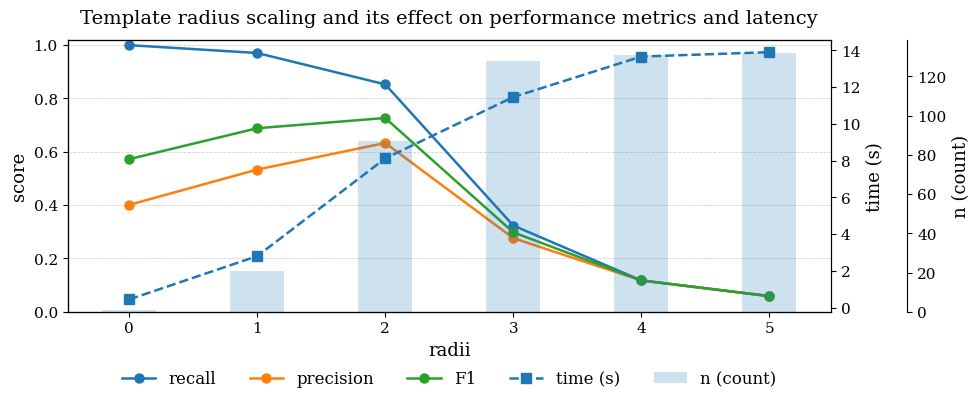

In [33]:
figs = plot_metrics_time_counts_compact(
    all,
    save_path=None,
    show=True,
    title='Template radius scaling and its effect on performance metrics and latency',
)

## 3. Choosing a radius in practice

A reasonable workflow:

1. Start with \(r=0\) to identify **core transformation types** (high generality).
2. Increase to \(r=1\) to reduce symmetry-induced ambiguity and “too-many matches”.
3. Use \(r=2\) or \(r=3\) if you need high precision (e.g., retrosynthesis planning),
   but expect lower coverage and more fragmented rule libraries.

If you see:
- **high branching at small \(r\)**: consider increasing \(r\), or tightening node/edge match predicates.
- **low coverage at large \(r\)**: consider decreasing \(r\), or normalizing charges/tautomers upstream.

> Important: context is not the only knob. In real pipelines, ranking (learned or heuristic),
> reagent handling, and stereochemistry decisions often dominate performance.


## 4. Exercises

1. **Backward evaluation.** Repeat the multi-radius study with `direction="backward"`.
   Is the best radius the same as forward?
2. **Center definition.** Modify `reaction_center_core_nodes` to include charge changes or exclude aromatic changes.
   How does the trade-off curve move?
3. **Hybrid context.** Implement a “ring-aware” expansion:
   if any core atom is in a ring, include the full ring as context (even if it exceeds radius).
